# 02 - Exploratory analysis

Figures for the data chapter. The point of this notebook is to establish why overall
accuracy is the wrong headline metric for this dataset before any model is trained.

NV alone is roughly two thirds of the images. A classifier that answers NV every single
time scores about 67% accuracy while detecting no melanoma at all, which is why the
write-up leads on per-class F1 and on recall for MEL and BCC.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA = ROOT / "data"
RUNS = ROOT / "runs"
print("repo:", ROOT)

repo: /workspace/ham10000-cnn-comparison


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from ham10000.constants import CLASS_NAMES
from ham10000.split import load_or_create_split

df, lesion_splits = load_or_create_split(DATA / "HAM10000_metadata.csv",
                                         RUNS / "splits" / "seed42_lesion_stratified.json")
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)
print(len(df), "images")

10015 images


## Class distribution

In [3]:
counts = df.dx.value_counts().reindex(CLASS_NAMES)
share = counts / counts.sum() * 100
summary = pd.DataFrame({"images": counts, "percent": share.round(2)})
summary["imbalance_vs_rarest"] = (counts / counts.min()).round(1)
print(summary)
print(f"\nMajority class share: {share.max():.1f}%")
print(f"Rarest class share:   {share.min():.1f}%")

       images  percent  imbalance_vs_rarest
dx                                         
akiec     327     3.27                  2.8
bcc       514     5.13                  4.5
bkl      1099    10.97                  9.6
df        115     1.15                  1.0
mel      1113    11.11                  9.7
nv       6705    66.95                 58.3
vasc      142     1.42                  1.2

Majority class share: 66.9%
Rarest class share:   1.1%


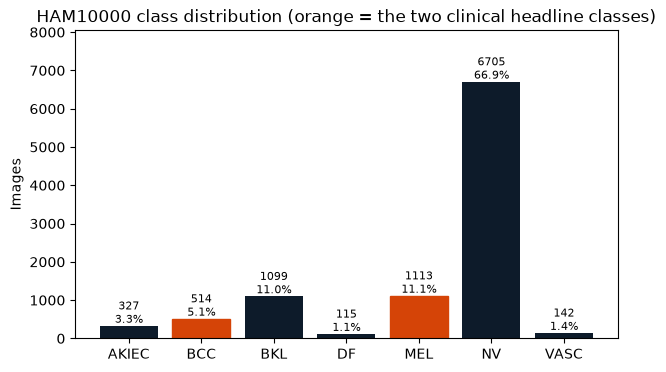

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([c.upper() for c in CLASS_NAMES], counts.values, color="#0D1B2A")
for c in ("mel", "bcc"):
    bars[CLASS_NAMES.index(c)].set_color("#D54407")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v}\n{v/counts.sum()*100:.1f}%",
            ha="center", fontsize=8)
ax.set_ylabel("Images")
ax.set_title("HAM10000 class distribution (orange = the two clinical headline classes)")
ax.set_ylim(0, counts.max() * 1.2)
fig.savefig(FIGS / "eda_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## The naive-baseline argument

Spelling this out explicitly because it is the single most useful sentence in the data
chapter.

In [5]:
majority = counts.idxmax()
naive_acc = counts.max() / counts.sum()
print(f"Always answering '{majority}' gives {naive_acc:.1%} accuracy")
print(f"and finds 0 of the {counts['mel']} melanomas.")
print(f"\nAny model reporting less than {naive_acc:.1%} accuracy is worse than a constant.")

Always answering 'nv' gives 66.9% accuracy
and finds 0 of the 1113 melanomas.

Any model reporting less than 66.9% accuracy is worse than a constant.


## Multiple images per lesion

In [6]:
per_lesion = df.groupby("lesion_id").size()
print(per_lesion.value_counts().sort_index().rename("lesions with N images"))
print(f"\n{(per_lesion > 1).sum()} lesions have more than one photograph.")
print("This is why the split is on lesion_id rather than image_id.")

1    5514
2    1423
3     490
4      34
5       5
6       4
Name: lesions with N images, dtype: int64

1956 lesions have more than one photograph.
This is why the split is on lesion_id rather than image_id.


## Where the split put everything

dx     akiec  bcc  bkl  df  mel    nv  vasc
split                                      
train    261  403  896  91  892  5354   115
val       33   58   98  11  106   661    12
test      33   53  105  13  115   690    15


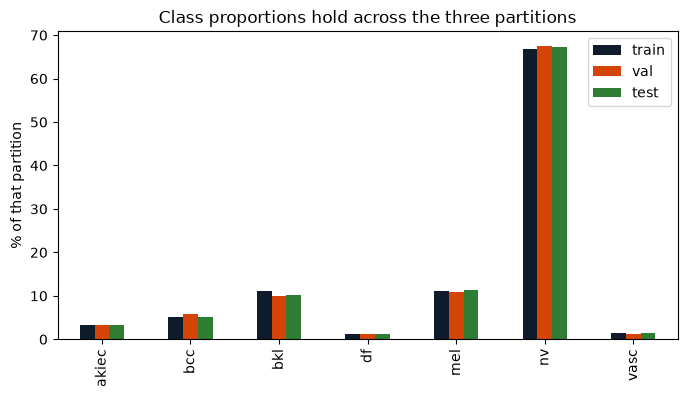

In [7]:
pivot = df.groupby(["split", "dx"]).size().unstack().reindex(
    ["train", "val", "test"])[CLASS_NAMES]
print(pivot.fillna(0).astype(int))

fig, ax = plt.subplots(figsize=(8, 4))
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pct.T.plot(kind="bar", ax=ax, color=["#0D1B2A", "#D54407", "#2E7D32"])
ax.set_ylabel("% of that partition")
ax.set_xlabel("")
ax.set_title("Class proportions hold across the three partitions")
ax.legend(title="")
fig.savefig(FIGS / "eda_split_proportions.png", dpi=200, bbox_inches="tight")
plt.show()

## Sample images

A quick look at what the model is actually being shown. Useful in the defence when
someone asks how visually separable these classes really are.

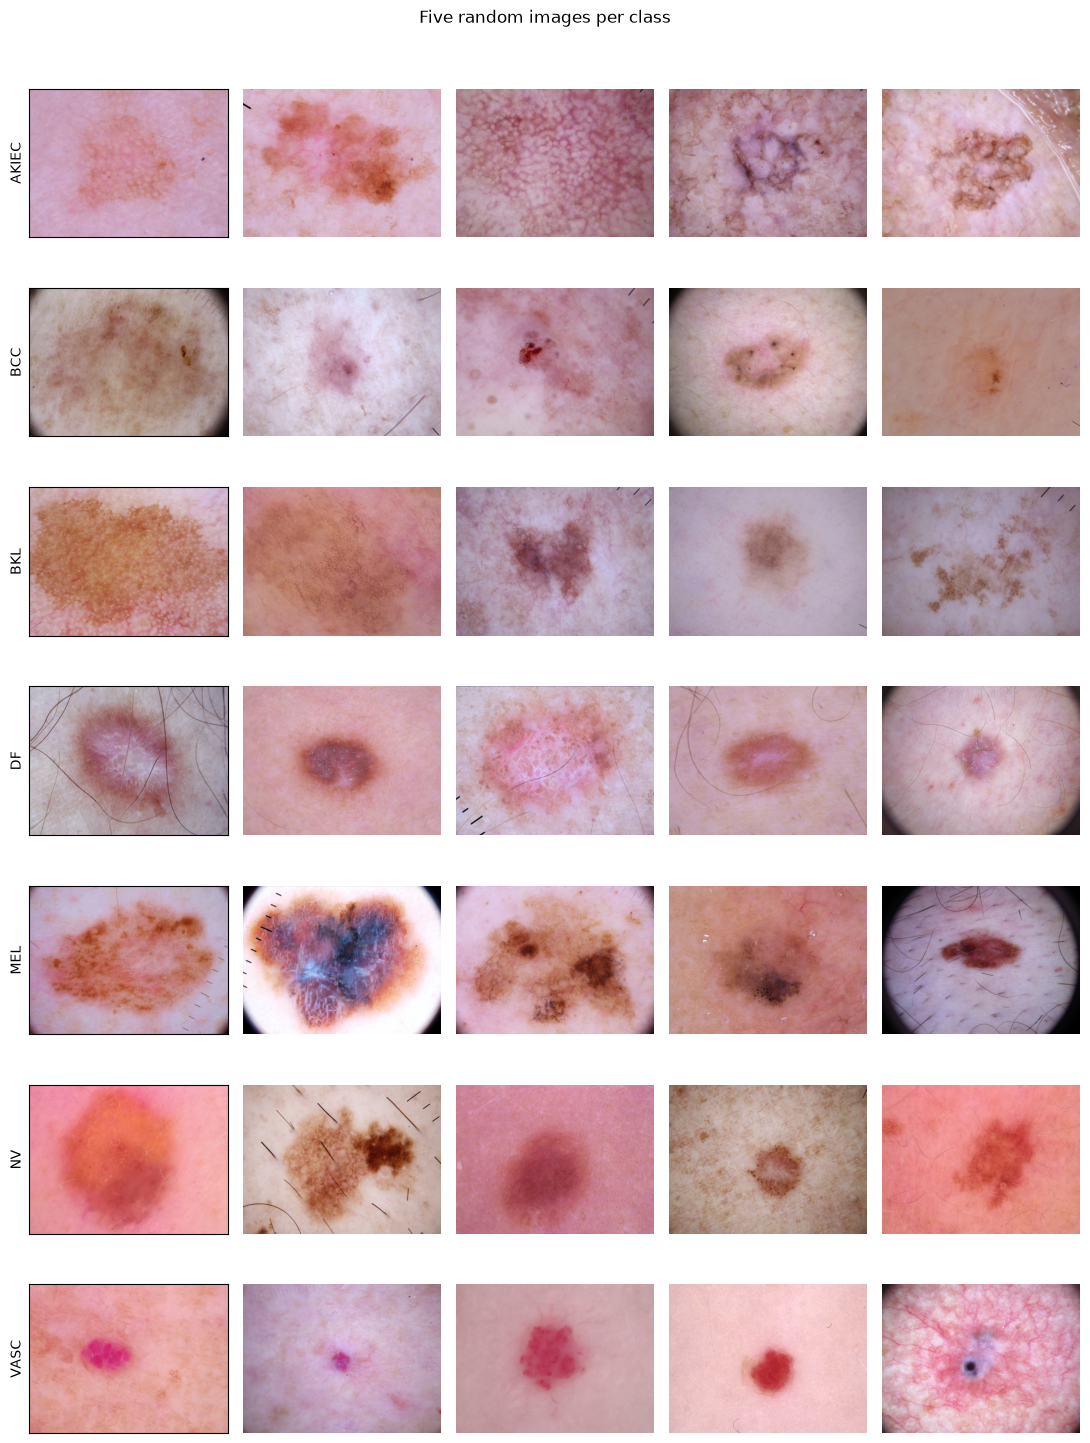

In [8]:
from PIL import Image
from ham10000.dataset import resolve_image_path

fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(11, 2.1 * len(CLASS_NAMES)))
for row, cls in enumerate(CLASS_NAMES):
    picks = df[df.dx == cls].sample(5, random_state=42)
    for col, (_, r) in enumerate(picks.iterrows()):
        axes[row][col].imshow(Image.open(resolve_image_path(DATA, r.image_id)))
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(cls.upper())
    axes[row][0].axis("on")
    axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
fig.suptitle("Five random images per class", y=1.0)
fig.tight_layout()
fig.savefig(FIGS / "eda_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## Class weights the weighted-CE runs will use

Computed here so the number is on record before E3, E4, E8 and E11 use it. The spread
between the largest and smallest weight is what makes those runs behave so differently
from the baselines.

In [9]:
from ham10000.imbalance import inverse_frequency_weights

train_labels = df[df.split == "train"].label.to_numpy()
w = inverse_frequency_weights(train_labels).numpy()
weights = pd.DataFrame({"class": CLASS_NAMES, "train_n": np.bincount(train_labels, minlength=7),
                        "weight": w.round(3)})
print(weights)
print(f"\nspread: {w.max()/w.min():.1f}x  ({w.min():.3f} to {w.max():.3f})")

   class  train_n  weight
0  akiec      261   4.385
1    bcc      403   2.840
2    bkl      896   1.277
3     df       91  12.578
4    mel      892   1.283
5     nv     5354   0.214
6   vasc      115   9.953

spread: 58.8x  (0.214 to 12.578)
